# Explainable Audio Deepfake Detection  
## Dataset Exploration (ASVspoof 2019 - Logical Access)

This notebook focuses on loading, understanding, and visualizing the dataset used for detecting audio deepfakes. We explore class distribution and inspect Mel spectrogram representations of real and synthetic speech.

## 1. Import Libraries

In [13]:
import os
import random
import librosa
import numpy as np
import matplotlib.pyplot as plt

## 2. Configuration

We define key parameters such as dataset paths, sampling rate, and Mel spectrogram settings. These configurations will be used consistently across the project.

In [14]:
DATA_PATH = "../data/ASVspoof2019_LA"
PROTOCOL_PATH = os.path.join(DATA_PATH, "ASVspoof2019_LA_cm_protocols")

SR = 16000
DURATION = 3
N_MELS = 128

## 3. Parse Dataset Protocol

The ASVspoof dataset provides protocol files that map each audio file to its label (real or fake).  
We parse this file to extract filenames and corresponding labels.

In [15]:
def parse_protocol(file_path):
    files, labels = [], []

    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            files.append(parts[1])
            labels.append(1 if parts[-1] == "spoof" else 0)

    return files, labels

## 4. Load Dataset

We load the dataset using the parsed protocol file and verify the total number of samples available.

In [16]:
train_protocol = os.path.join(
    PROTOCOL_PATH,
    "ASVspoof2019.LA.cm.train.trn.txt"
)

filenames, labels = parse_protocol(train_protocol)

print("Total samples:", len(filenames))

Total samples: 25380


## 5. Class Distribution

We analyze the distribution of real (bonafide) and fake (spoof) samples to understand dataset balance.

In [17]:
import collections

counter = collections.Counter(labels)

print("Class distribution:")
print("Real (0):", counter[0])
print("Fake (1):", counter[1])

Class distribution:
Real (0): 2580
Fake (1): 22800


## 6. Audio to Mel Spectrogram Conversion

Audio signals are converted into Mel spectrograms, which provide a time-frequency representation of sound.  
These spectrograms will serve as input to our deep learning models.

In [18]:
def audio_to_mel(path):
    y, _ = librosa.load(path, sr=SR)

    max_len = SR * DURATION
    y = y[:max_len] if len(y) > max_len else np.pad(y, (0, max_len - len(y)))

    mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS)
    mel = librosa.power_to_db(mel, ref=np.max)

    return mel

## 7. Visualization Function

We define a helper function to visualize Mel spectrograms for better interpretability.

In [19]:
def plot_mel(mel, title="Mel Spectrogram"):
    plt.figure(figsize=(6,4))
    plt.imshow(mel, aspect='auto', origin='lower')
    plt.title(title)
    plt.colorbar()
    plt.show()

## 8. Real vs Fake Audio Visualization

We visualize one real and one fake audio sample to observe differences in their spectrogram patterns.  
This helps build intuition about the characteristics of synthetic speech.

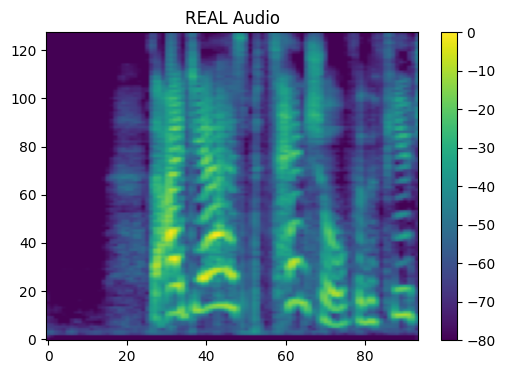

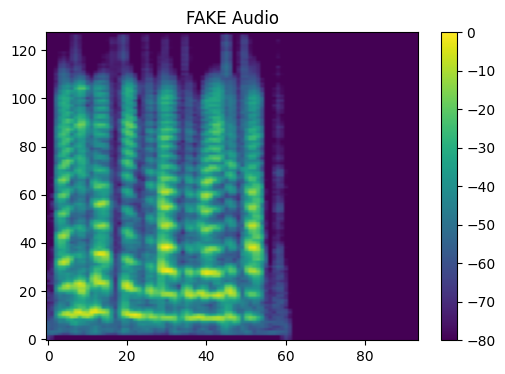

In [20]:
# Find one real and one fake sample

real_sample = None
fake_sample = None

for f, l in zip(filenames, labels):
    if l == 0 and real_sample is None:
        real_sample = f
    elif l == 1 and fake_sample is None:
        fake_sample = f
    
    if real_sample and fake_sample:
        break

real_path = os.path.join(DATA_PATH, "ASVspoof2019_LA_train/flac", real_sample + ".flac")
fake_path = os.path.join(DATA_PATH, "ASVspoof2019_LA_train/flac", fake_sample + ".flac")

real_mel = audio_to_mel(real_path)
fake_mel = audio_to_mel(fake_path)

plot_mel(real_mel, "REAL Audio")
plot_mel(fake_mel, "FAKE Audio")

## 9. Multiple Sample Visualization

We display multiple random samples from the dataset to further explore variability in both real and fake audio.

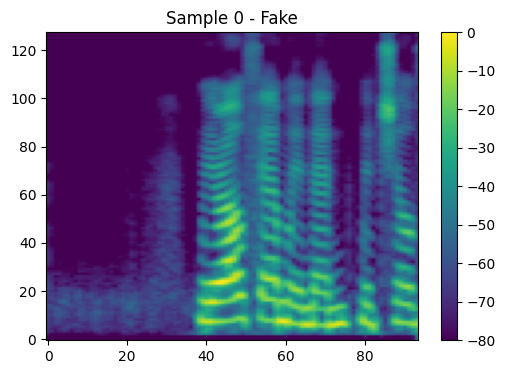

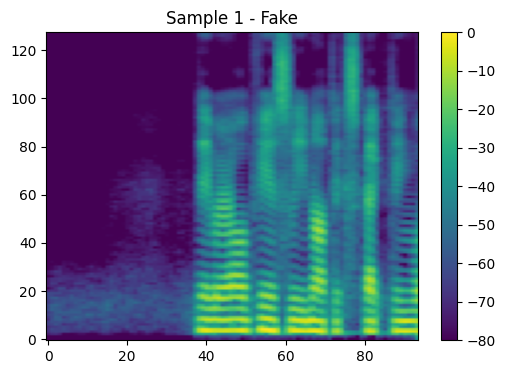

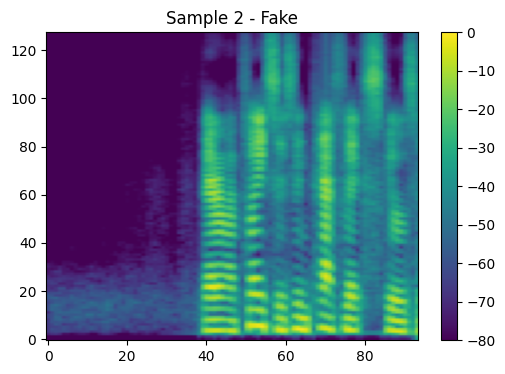

In [21]:
for i in range(3):
    idx = random.randint(0, len(filenames)-1)
    
    path = os.path.join(DATA_PATH, "ASVspoof2019_LA_train/flac", filenames[idx] + ".flac")
    mel = audio_to_mel(path)

    label = "Fake" if labels[idx] else "Real"
    plot_mel(mel, f"Sample {i} - {label}")

## 10. Key Observations

- Real audio tends to show smoother and more continuous spectral patterns.
- Fake audio may exhibit irregularities or unnatural high-frequency components.
- These differences motivate the use of deep learning models to automatically learn discriminative features.

This exploration sets the foundation for model training and explainability analysis in subsequent notebooks.